# AI-Powered Retail Report Analysis with Retrieval-Augmented Generation (RAG)

## 1. Business Problem & Project Objective

### Business Problem

Retail industry reports contain valuable information about market trends, consumer behavior, cost pressures, and business strategies. However, manually reviewing lengthy reports to locate relevant evidence and synthesize insights can be time-consuming for business and data analysts.

Analysts need a more efficient way to retrieve relevant evidence from lengthy reports, synthesize it into decision-relevant insights, and generate evidence-based answers while maintaining traceability to the source material.

### Project Objective

This project develops and evaluates a Retrieval-Augmented Generation (RAG) system for retail report analysis.

Using a 2025 Deloitte retail and consumer trends report as the primary case study, the system retrieves relevant document chunks from a FAISS vector store and provides the retrieved content as context to a language model to generate document-grounded answers to business questions.

The project aims to:

- Build a document-based RAG pipeline for retail report analysis.
- Retrieve relevant evidence from the report for business-focused questions.
- Generate answers grounded in the retrieved source content.
- Evaluate how chunk size and top-K retrieval depth affect retrieval relevance, answer quality, and source grounding.
- Test whether document cleaning reduces retrieval noise from non-substantive report sections.
- Compare RAG-generated answers with responses from a baseline LLM without document retrieval.
- Extract and communicate key business insights from the report.


### Technologies

**Core stack:** Python · LangChain · OpenAI API · FAISS · Pandas · Streamlit  
**AI methods:** Retrieval-Augmented Generation (RAG) · OpenAI Embeddings · Semantic Search



## 2. Environment Setup

This section installs and imports the libraries required to build the RAG pipeline and configures access to the OpenAI API.


In [1]:
!pip install -q \
    requests==2.32.4 \
    openai \
    pypdf \
    faiss-cpu \
    langchain \
    langchain-community \
    langchain-openai \
    langchain-text-splitters

In [2]:
import os
import pandas as pd

from importlib.metadata import version
from google.colab import userdata, files

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

print("LangChain:", version("langchain"))
print("LangChain OpenAI:", version("langchain-openai"))
print("OpenAI:", version("openai"))

LangChain: 0.3.30
LangChain OpenAI: 0.3.35
OpenAI: 2.54.0


In [3]:
# Load API key
api_key = userdata.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError(
        "OPENAI_API_KEY not found. Please add it to the Colab Secrets panel."
    )

os.environ["OPENAI_API_KEY"] = api_key

# Initialize language model
LLM_MODEL = "gpt-5.6"

llm = ChatOpenAI(
    model=LLM_MODEL
)

print("OpenAI API key loaded successfully.")
print("LLM model:", llm.model_name)

OpenAI API key loaded successfully.
LLM model: gpt-5.6


## 3. Document Loading

The 2025 Deloitte retail and consumer trends report is loaded using `PyPDFLoader`. Each PDF page is converted into a LangChain document containing the extracted text and page-level metadata, which is later used to trace retrieved chunks back to their source pages.


In [4]:
uploaded = files.upload()

if not uploaded:
    raise ValueError("No PDF file was uploaded.")

pdf_filename = next(iter(uploaded))
pdf_path = f"/content/{pdf_filename}"

print("Uploaded PDF:", pdf_filename)

loader = PyPDFLoader(pdf_path)
documents = loader.load()

print(f"Number of pages loaded: {len(documents)}")
print("Sample metadata:", documents[0].metadata)

Saving deloitte-q2-2025-emerging-retail-and-consumer-trends.pdf to deloitte-q2-2025-emerging-retail-and-consumer-trends (4).pdf
Uploaded PDF: deloitte-q2-2025-emerging-retail-and-consumer-trends (4).pdf
Number of pages loaded: 9
Sample metadata: {'producer': 'Adobe PDF Library 17.0', 'creator': 'Adobe InDesign 20.5 (Macintosh)', 'creationdate': '2025-08-26T12:34:39+05:30', 'moddate': '2025-08-26T10:14:04-04:00', 'title': 'Q2 2025 Emerging retail consumer trends', 'trapped': '/False', 'source': '/content/deloitte-q2-2025-emerging-retail-and-consumer-trends (4).pdf', 'total_pages': 9, 'page': 0, 'page_label': '1'}


## 4. Text Splitting

The loaded report is divided into smaller text chunks using `RecursiveCharacterTextSplitter`. Chunking allows the retriever to identify specific sections of the report that are relevant to a user's question.

Multiple chunk sizes are evaluated later in the notebook to examine how chunk granularity affects retrieval and downstream answer quality. Chunk overlap is held constant at **150 characters** across all tested configurations.

A chunk size of 500 characters is used here as the initial configuration and is later compared with alternative chunk sizes.

In [5]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=150
)

chunks = text_splitter.split_documents(documents)

print(f"Number of pages: {len(documents)}")
print(f"Number of chunks: {len(chunks)}")

Number of pages: 9
Number of chunks: 39


## 5. Embeddings

An OpenAI embedding model is initialized to convert text chunks into numerical vector representations. These embeddings capture semantic relationships in the text, allowing the system to compare user questions with report content and retrieve semantically relevant chunks.

The embedding model used in this project is `text-embedding-3-large`.

In [6]:
EMBEDDING_MODEL = "text-embedding-3-large"

embeddings = OpenAIEmbeddings(
    model=EMBEDDING_MODEL
)

print("Embedding model:", EMBEDDING_MODEL)

Embedding model: text-embedding-3-large


## 6. FAISS Vector Store

The document chunks are embedded and stored in a FAISS vector store. FAISS performs vector similarity search between an embedded user query and the stored document vectors, allowing the system to retrieve semantically similar chunks from the report.


In [7]:
vectorstore = FAISS.from_documents(
    chunks,
    embeddings
)

print(f"FAISS vector store created with {len(chunks)} chunks.")

FAISS vector store created with 39 chunks.


## 7. Retriever & Similarity Search

The FAISS vector store is exposed as a retriever that returns the Top-K document chunks most similar to a business question.

For the initial RAG configuration, Top-K = 5 is used. This setting is later compared with alternative retrieval depths in Experiment 1.

A sample similarity search is shown below to illustrate how the system retrieves evidence and traces each result back to its source page.

In [8]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

print("Retriever configured to return the top 5 semantically similar chunks.")

Retriever configured to return the top 5 semantically similar chunks.


In [9]:
test_question = "What are the main challenges facing the retail industry?"

results = vectorstore.similarity_search_with_score(
    test_question,
    k=5
)

for i, (doc, score) in enumerate(results, start=1):
    page = doc.metadata.get("page", "N/A")

    if page != "N/A":
        page += 1

    print(f"\n--- Result {i} ---")
    print(f"Page: {page}")
    print(f"FAISS Distance Score: {score:.4f}")
    print(doc.page_content[:250].replace("\n", " "))


--- Result 1 ---
Page: 5
FAISS Distance Score: 1.1000
alternatives.  • Lean on loyalty programs and points to enhance  customer experience and encourage engagement. Product assortment restructuring Resilient assortment planning has emerged as a strategy  for some retailers such as TJX Companies, owner o

--- Result 2 ---
Page: 3
FAISS Distance Score: 1.1139
RCP Trends Report  | Q2 2025 03 Introduction As the trade landscape shifts with the introduction of new  tariffs, retail and consumer goods businesses may face  uncertainty related to cost, profit margins, and growing  complexity across global supply

--- Result 3 ---
Page: 1
FAISS Distance Score: 1.1345
Q2 2025  Emerging retail and  consumer trends

--- Result 4 ---
Page: 5
FAISS Distance Score: 1.1369
RCP Trends Report  | Q2 2025 05 Keeping consumers first: Delivering value while  preserving trust Marketing and communications In response to rising consumer concern over price  uncertainty, many retailers have pledged to bear part 

## 8. RAG Question Answering

The retriever is combined with the language model to create the complete RAG question-answering pipeline.

For each business question, the system retrieves the **Top-5** semantically similar chunks and provides them as context to the language model. The prompt instructs the model to answer only from the retrieved context and to acknowledge when the available evidence is insufficient.

The retrieved source pages are also displayed to provide traceability between the generated answer and the source document.

In [10]:
prompt = ChatPromptTemplate.from_template(
    """Use the following retrieved context to answer the question.
Answer only from the provided context.
If the answer is not in the context, say you do not know.

Context:
{context}

Question:
{question}
"""
)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

print("RAG pipeline created successfully.")

question = "What are the main challenges facing the retail industry?"

# Retrieve supporting chunks
source_documents = retriever.invoke(question)

# Format retrieved context
context = format_docs(source_documents)

# Generate answer
rag_chain = (
    prompt
    | llm
    | StrOutputParser()
)

response = rag_chain.invoke({
    "context": context,
    "question": question
})

print("Question:")
print(question)

print("\nAnswer:")
print(response)

source_pages = []

for doc in source_documents:
    page = doc.metadata.get("page", "N/A")

    if page != "N/A":
        page += 1

    if page not in source_pages:
        source_pages.append(page)

print("\nSource Pages:")
print(", ".join(map(str, source_pages)))

RAG pipeline created successfully.
Question:
What are the main challenges facing the retail industry?

Answer:
The main challenges facing retailers are:

- New tariffs creating uncertainty around costs and profit margins.
- Increasing complexity across global supply chains.
- Price-sensitive consumers changing their spending habits.
- Preserving customer trust and value while absorbing potential price increases.
- Managing inventory, including the risk of excess stock if demand weakens.
- Accurately anticipating shifts in consumer demand and maintaining supply-chain agility.

Source Pages:
5, 3, 1, 4


## 9. Business Question Analysis

Five business-focused questions are used to evaluate the RAG system across key themes in the retail report: industry challenges, tariff impacts, cost pressures, consumer behavior, and retailer strategies.

These questions are used consistently throughout the subsequent experiments, allowing retrieval and answer quality to be compared across different RAG configurations.


In [11]:
business_questions = {
    "Industry Challenges":
        "What are the main challenges facing the retail industry?",

    "Tariff Impact":
        "How are tariffs affecting retailers and consumers?",

    "Cost Pressure":
        "What cost pressures are retailers facing?",

    "Consumer Trends":
        "How are consumers changing their shopping behavior in response to price increases?",

    "Retail Strategies":
        "What strategies are retailers using to manage cost pressures while maintaining consumer trust?"
}

business_results = {}

for category, question in business_questions.items():

    # Retrieve supporting chunks
    source_documents = retriever.invoke(question)

    # Format retrieved context
    context = format_docs(source_documents)

    # Generate answer using the retrieved context
    answer = rag_chain.invoke({
        "context": context,
        "question": question
    })

    business_results[category] = {
        "question": question,
        "answer": answer,
        "sources": source_documents
    }

print("Business questions analyzed:", len(business_results))

Business questions analyzed: 5


## 10. Experiment 1: Retrieval Configuration Comparison

RAG performance depends not only on chunk size, but also on the number of document chunks retrieved for each question.

This experiment compares six retrieval configurations by varying:

- Chunk size: 500, 800, 1100 characters
- Top-K retrieval depth: 3, 5
- Chunk overlap: fixed at 150 characters
- Same embedding model
- Same language model
- Same evaluation questions

The goal is to compare how these retrieval configurations affect both **retrieval quality** and **downstream answer quality**, including relevance, completeness, and grounding.

This is a small-scale comparative experiment across six selected configurations rather than an exhaustive hyperparameter search.

In [12]:
chunk_sizes = [500, 800, 1100]
top_k_values = [3, 5]
chunk_overlap = 150

rag_experiments = {}

for chunk_size in chunk_sizes:

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )

    experiment_chunks = splitter.split_documents(documents)

    experiment_vectorstore = FAISS.from_documents(
        experiment_chunks,
        embeddings
    )

    for top_k in top_k_values:

        retriever_exp = experiment_vectorstore.as_retriever(
            search_kwargs={"k": top_k}
        )

        config_name = f"chunk_{chunk_size}_k_{top_k}"

        rag_experiments[config_name] = {
            "chunk_size": chunk_size,
            "top_k": top_k,
            "num_chunks": len(experiment_chunks),
            "retriever": retriever_exp
        }

        print(
            f"{config_name}: "
            f"{len(experiment_chunks)} chunks"
        )

chunk_500_k_3: 39 chunks
chunk_500_k_5: 39 chunks
chunk_800_k_3: 25 chunks
chunk_800_k_5: 25 chunks
chunk_1100_k_3: 18 chunks
chunk_1100_k_5: 18 chunks


In [13]:
experiment_results = {}

for config_name, config in rag_experiments.items():

    experiment_results[config_name] = {}

    for category, question in business_questions.items():

        # Retrieve supporting chunks once
        retrieved_docs = config["retriever"].invoke(question)

        # Format retrieved context
        context = format_docs(retrieved_docs)

        # Generate answer using the same prompt and LLM
        response = rag_chain.invoke({
            "context": context,
            "question": question
        })

        experiment_results[config_name][category] = {
            "question": question,
            "response": response,
            "retrieved_docs": retrieved_docs
        }

print(
    "Experiment responses generated:",
    sum(len(results) for results in experiment_results.values())
)


Experiment responses generated: 30


In [14]:
rows = []

for config_name, config_results in experiment_results.items():

    config_info = rag_experiments[config_name]

    for category, result in config_results.items():

        retrieved_pages = []

        for doc in result["retrieved_docs"]:
            page = doc.metadata.get("page", "N/A")

            if page != "N/A":
                page += 1

            if page not in retrieved_pages:
                retrieved_pages.append(page)

        rows.append({
            "Configuration": config_name,
            "Chunk Size": config_info["chunk_size"],
            "Top K": config_info["top_k"],
            "Category": category,
            "Question": result["question"],
            "Response": result["response"],
            "Retrieved Pages": retrieved_pages
        })

results_df = pd.DataFrame(rows)

print("Evaluation rows:", len(results_df))
print("Configurations:", results_df["Configuration"].nunique())
print(
    "Questions per configuration:",
    results_df.groupby("Configuration").size().unique()
)

Evaluation rows: 30
Configurations: 6
Questions per configuration: [5]


## 11. Evaluation

### Evaluation Criteria

Each RAG response was manually evaluated using three criteria on a 1–3 scale. Relevance and completeness were assessed based on answer quality, while grounding was evaluated by comparing the generated claims with the retrieved document evidence.

**Relevance**
- 3: Directly answers the business question with relevant information.
- 2: Partially answers the question but misses some important aspects.
- 1: Mostly irrelevant or does not adequately answer the question.

**Completeness**
- 3: Covers most or all key information needed to answer the question based on the relevant evidence identified in the source report.
- 2: Covers some key information but misses notable report-supported points.
- 1: Misses most of the important report-supported information.

**Grounding**
- 3: All or almost all claims are supported by the retrieved document content.
- 2: Most claims are supported, but some claims are weakly supported.
- 1: Important claims are unsupported or inconsistent with the retrieved content.

For each configuration, scores are averaged across the five evaluation questions for each criterion. The three criterion averages are then summed to produce an overall answer-quality score out of 9.0.

For each question and configuration, the generated response was manually reviewed alongside its retrieved chunks. Scores and short evaluation rationales were then recorded in `results_df` for comparison across configurations.

In [15]:
results_df["Relevance"] = None
results_df["Completeness"] = None
results_df["Grounding"] = None
results_df["Evaluation Rationale"] = None

In [16]:
for config_name in ["chunk_500_k_3", "chunk_500_k_5"]:

    result = experiment_results[config_name]["Industry Challenges"]

    print("\n" + "=" * 80)
    print("CONFIGURATION:", config_name)

    print("\nQUESTION:")
    print(result["question"])

    print("\nRESPONSE:")
    print(result["response"])

    print("\nRETRIEVED EVIDENCE:")

    for i, doc in enumerate(result["retrieved_docs"], start=1):
        page = doc.metadata.get("page", "N/A")

        if page != "N/A":
            page += 1

        print(f"\n--- Chunk {i} | Page {page} ---")
        print(doc.page_content)


CONFIGURATION: chunk_500_k_3

QUESTION:
What are the main challenges facing the retail industry?

RESPONSE:
The main challenges are:

- New tariffs and a shifting trade landscape
- Uncertainty around costs and profit margins
- Increasing complexity across global supply chains
- Consumer sensitivity to price increases, potentially causing shifts in spending habits
- The need to restructure product assortments to remain resilient

RETRIEVED EVIDENCE:

--- Chunk 1 | Page 5 ---
alternatives.
 • Lean on loyalty programs and points to enhance 
customer experience and encourage engagement.
Product assortment restructuring
Resilient assortment planning has emerged as a strategy 
for some retailers such as TJX Companies, owner of 
discount department store chains TJ Maxx, Marshalls, and 
HomeGoods. CEO Ernie Herrman expressed confidence in 
managing possible impacts from tariffs through effective 
assortment planning: “The good thing with our flexibility

--- Chunk 2 | Page 3 ---
RCP Trends Re

In [17]:
industry_scores = {
    "chunk_500_k_3":  [3, 2, 3],
    "chunk_500_k_5":  [3, 3, 3],
    "chunk_800_k_3":  [3, 3, 3],
    "chunk_800_k_5":  [3, 3, 3],
    "chunk_1100_k_3": [3, 2, 3],
    "chunk_1100_k_5": [3, 3, 3]
}

industry_rationales = {
    "chunk_500_k_3":
    "Highly relevant and well grounded, but the answer misses some report-supported challenges "
    "such as inventory risk and demand forecasting, reducing completeness.",

    "chunk_500_k_5":
        "Directly answers the question and covers the main challenges across tariffs, margins, "
        "supply-chain complexity, consumer behavior, inventory risk, and demand forecasting. "
        "The claims are supported by the retrieved evidence.",

    "chunk_800_k_3":
        "The retrieved evidence covers the major industry challenges, including tariffs, margins, "
        "consumer demand, inventory risk, and supply-chain agility. The answer is relevant, complete, "
        "and grounded in the retrieved document content.",

    "chunk_800_k_5":
        "Provides broad coverage of the main challenges, including tariffs, margin pressure, "
        "consumer demand, trust, inventory risk, and supply-chain resilience. The retrieved evidence "
        "supports the claims made in the answer.",

   "chunk_1100_k_3":
    "The answer is relevant and well supported, but it misses some important report-supported "
    "challenges such as inventory risk and demand forecasting, reducing completeness.",

    "chunk_1100_k_5":
        "Covers the key challenges across tariffs, margins, supply chains, consumer behavior, "
        "inventory risk, and demand forecasting. The claims are consistent with the retrieved evidence."
}

for config, scores in industry_scores.items():

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Industry Challenges"),
        ["Relevance", "Completeness", "Grounding"]
    ] = scores

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Industry Challenges"),
        "Evaluation Rationale"
    ] = industry_rationales[config]

In [18]:
for config_name in ["chunk_800_k_3", "chunk_800_k_5"]:

    result = experiment_results[config_name]["Tariff Impact"]

    print("\n" + "=" * 80)
    print("CONFIGURATION:", config_name)

    print("\nQUESTION:")
    print(result["question"])

    print("\nRESPONSE:")
    print(result["response"])

    print("\nRETRIEVED EVIDENCE:")

    for i, doc in enumerate(result["retrieved_docs"], start=1):
        page = doc.metadata.get("page", "N/A")

        if page != "N/A":
            page += 1

        print(f"\n--- Chunk {i} | Page {page} ---")
        print(doc.page_content)


CONFIGURATION: chunk_800_k_3

QUESTION:
How are tariffs affecting retailers and consumers?

RESPONSE:
Tariffs are increasing retailers’ costs and forcing them to consider several responses:

- **Limited consumer price increases**, generally described as a “very last resort.”
- **Maintaining prices while removing certain products or categories from shelves.**
- **Changing supply chains and using store/private-label brands** to offset costs.
- **Adjusting promotions and clearly communicating price changes** to preserve customer trust and loyalty.

For consumers, the effects may include higher prices, fewer product choices, and greater reliance on private-label alternatives.

RETRIEVED EVIDENCE:

--- Chunk 1 | Page 8 ---
Press, May 28, 2025.
13.  Steve Kopack and J.J. McCorvey, “Target calls price hikes a ‘very last resort’ for offsetting tariffs as sales slump,”  NBC News, May 21, 2025.
14.  SGB Media, “Study: Why retailers risk loyalty with tariff-based price hikes.”
15.  Vidhi Choudha

In [19]:
tariff_scores = {
    "chunk_500_k_3":  [3, 3, 3],
    "chunk_500_k_5":  [3, 3, 3],
    "chunk_800_k_3":  [3, 2, 3],
    "chunk_800_k_5":  [3, 3, 3],
    "chunk_1100_k_3": [3, 3, 3],
    "chunk_1100_k_5": [3, 3, 3]
}

tariff_rationales = {
    "chunk_500_k_3":
        "The answer directly addresses the effects of tariffs on retailers and consumers, covering pricing, "
        "inventory, production shifts, cost optimization, and product availability. The main claims are "
        "supported by the retrieved evidence.",

    "chunk_500_k_5":
        "The answer provides complete coverage of retailer and consumer impacts, including selective pricing, "
        "inventory actions, supply-chain responses, product availability, and private-label strategies. "
        "The claims are supported by the retrieved evidence.",

   "chunk_800_k_3":
    "The answer is relevant and well grounded, covering pricing, product availability, store brands, "
    "promotions, and customer trust. However, it misses some report-supported operational responses, "
    "such as inventory actions, production shifts, and cost optimization, reducing completeness.",

    "chunk_800_k_5":
        "The answer provides broad coverage of tariff impacts and retailer responses, including cost absorption, "
        "selective pricing, supply-chain adjustments, inventory actions, product assortment, store brands, "
        "and consumer communication. The claims are well supported by the retrieved evidence.",

    "chunk_1100_k_3":
        "The answer thoroughly covers pricing, promotions, loyalty programs, product assortment, and consumer "
        "impacts. The detailed retrieved evidence directly supports the claims made in the answer.",

    "chunk_1100_k_5":
        "The answer provides comprehensive coverage of pricing, supplier cost sharing, supply-chain diversification, "
        "domestic sourcing, assortment restructuring, promotions, and consumer value strategies. "
        "The claims are supported by the retrieved evidence."
}

for config, scores in tariff_scores.items():

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Tariff Impact"),
        ["Relevance", "Completeness", "Grounding"]
    ] = scores

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Tariff Impact"),
        "Evaluation Rationale"
    ] = tariff_rationales[config]

In [20]:
for config_name in ["chunk_500_k_3", "chunk_500_k_5"]:

    result = experiment_results[config_name]["Cost Pressure"]

    print("\n" + "=" * 80)
    print("CONFIGURATION:", config_name)

    print("\nQUESTION:")
    print(result["question"])

    print("\nRESPONSE:")
    print(result["response"])

    print("\nRETRIEVED EVIDENCE:")

    for i, doc in enumerate(result["retrieved_docs"], start=1):
        page = doc.metadata.get("page", "N/A")

        if page != "N/A":
            page += 1

        print(f"\n--- Chunk {i} | Page {page} ---")
        print(doc.page_content)


CONFIGURATION: chunk_500_k_3

QUESTION:
What cost pressures are retailers facing?

RESPONSE:
Retailers are facing potential tariff-related price increases, tightening margins, and broader economic pressures that are driving them to optimize costs.

RETRIEVED EVIDENCE:

--- Chunk 1 | Page 5 ---
have great value on the goods that we put out there.”17 
Even so, other retailers have seen successes too. Target 
cited that it will be committing to reevaluating assortment 
decisions, diversifying production origin, and adjusting 
order timing and prices as possible levers in mitigating 
potential price increases.18 
Other retailers are prioritizing private labels as a strategy 
to build more price-stable product mixes. Private-brand 
products cost 20% less than national brands and the

--- Chunk 2 | Page 5 ---
RCP Trends Report  | Q2 2025
05
Keeping consumers first: Delivering value while 
preserving trust
Marketing and communications
In response to rising consumer concern over price 
uncert

In [21]:
cost_pressure_scores = {
    "chunk_500_k_3":  [3, 2, 3],
    "chunk_500_k_5":  [3, 3, 3],
    "chunk_800_k_3":  [3, 2, 3],
    "chunk_800_k_5":  [3, 3, 3],
    "chunk_1100_k_3": [3, 2, 3],
    "chunk_1100_k_5": [3, 3, 3]
}

cost_pressure_rationales = {
   "chunk_500_k_3":
    "The answer is relevant and grounded in the retrieved evidence, identifying tariff-related costs, "
    "price uncertainty, and margin pressure. However, it provides limited coverage of additional "
    "report-supported cost pressures such as global supply-chain complexity and sourcing-related pressures.",

    "chunk_500_k_5":
        "The answer clearly identifies tariffs, profit-margin pressure, price uncertainty, and growing "
        "global supply-chain complexity. It also explains the pressure to absorb tariff-related costs, "
        "with the claims supported by the retrieved evidence.",

    "chunk_800_k_3":
        "The answer is relevant and well grounded, covering tightening margins, tariff-related cost increases, "
        "cost absorption, selective price increases, and product removal. However, it misses broader cost "
        "pressures such as global supply-chain complexity and vendor-related cost management.",

    "chunk_800_k_5":
        "The answer provides broad coverage of cost pressures, including tariffs, tightening margins, "
        "global supply-chain complexity, vendor negotiations, sourcing diversification, cost absorption, "
        "selective pricing, and product assortment decisions. The claims are well supported by the retrieved evidence.",

    "chunk_1100_k_3":
        "The answer is relevant and grounded, covering tariffs, tighter margins, price uncertainty, cost absorption, "
        "assortment changes, sourcing diversification, order timing, and private-label strategies. However, "
        "it does not fully capture broader supply-chain complexity and other cost-management pressures.",

    "chunk_1100_k_5":
        "The answer directly identifies the major cost pressures of tariffs, tightening margins, price uncertainty, "
        "and global supply-chain complexity. It also explains that retailers are absorbing some costs, "
        "and the claims are supported by the retrieved evidence."
}

for config, scores in cost_pressure_scores.items():

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Cost Pressure"),
        ["Relevance", "Completeness", "Grounding"]
    ] = scores

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Cost Pressure"),
        "Evaluation Rationale"
    ] = cost_pressure_rationales[config]

In [22]:
for config_name in [
    "chunk_500_k_5",
    "chunk_800_k_5",
    "chunk_1100_k_5"
]:

    result = experiment_results[config_name]["Consumer Trends"]

    print("\n" + "=" * 80)
    print("CONFIGURATION:", config_name)

    print("\nQUESTION:")
    print(result["question"])

    print("\nRESPONSE:")
    print(result["response"])

    print("\nRETRIEVED EVIDENCE:")

    for i, doc in enumerate(result["retrieved_docs"], start=1):

        page = doc.metadata.get("page", "N/A")

        if page != "N/A":
            page += 1

        print(f"\n--- Chunk {i} | Page {page} ---")
        print(doc.page_content)


CONFIGURATION: chunk_500_k_5

QUESTION:
How are consumers changing their shopping behavior in response to price increases?

RESPONSE:
Thirty percent of surveyed shoppers say any price increase would cause them to shift their spending habits. Additionally, 79% have pledged loyalty to brands that fully absorb tariff-related costs rather than passing them on through higher prices.

RETRIEVED EVIDENCE:

--- Chunk 1 | Page 3 ---
anticipated changes: 30%1 of shoppers surveyed say that any 
price increase would cause them to shift spending habits, 
and 79%2 have pledged loyalty to brands that fully absorb the 
potential cost of tariffs. To stay competitive, some companies 
are prioritizing two key strategies: investing in technology 
to modernize and increase the agility of their supply chains, 
and adopting consumer-focused approaches in pricing, 
promotion, and assortment planning. By combining supply

--- Chunk 2 | Page 5 ---
have great value on the goods that we put out there.”17 
Even s

In [23]:
consumer_trends_scores = {
    "chunk_500_k_3":  [3, 3, 3],
    "chunk_500_k_5":  [3, 3, 3],
    "chunk_800_k_3":  [3, 2, 3],
    "chunk_800_k_5":  [3, 2, 3],
    "chunk_1100_k_3": [3, 2, 3],
    "chunk_1100_k_5": [2, 2, 2]
}

consumer_trends_rationales = {
    "chunk_500_k_3":
        "The answer directly addresses changes in consumer behavior using the strongest retrieved evidence: "
        "30% of surveyed shoppers would shift spending habits after a price increase, while 79% expressed "
        "loyalty to brands that absorb tariff-related costs. The claims are fully supported by the retrieved evidence.",

    "chunk_500_k_5":
        "The answer directly identifies the two key consumer behavior findings in the report: changes in "
        "spending habits and stronger loyalty toward brands that absorb tariff costs. The additional retrieved "
        "chunks provide relevant context, and the answer remains fully grounded.",

    "chunk_800_k_3":
        "The answer is relevant and grounded in retrieved evidence showing that pre-tariff promotions encouraged "
        "immediate purchases. However, the retrieval misses the stronger Page 3 evidence on broader spending-habit "
        "changes and brand loyalty, limiting completeness.",

    "chunk_800_k_5":
        "The answer correctly identifies earlier purchasing behavior in response to anticipated price increases "
        "and supports it with the Tariff Sale example. However, even with a higher Top-K, the retrieval does not "
        "capture the Page 3 evidence on spending shifts and brand loyalty, so the answer remains incomplete.",

    "chunk_1100_k_3":
        "The answer appropriately limits its claims to the retrieved evidence and identifies immediate purchasing "
        "triggered by pre-tariff promotions. However, the retrieval misses the broader consumer behavior evidence "
        "on spending changes and loyalty, reducing completeness.",

    "chunk_1100_k_5":
    "The response is only partially relevant because it declines to answer the question even though the retrieved evidence shows immediate purchases triggered by pre-tariff promotions. "
    "The retrieval also misses the stronger Page 3 evidence on broader spending-habit changes and brand loyalty. "
    "In addition, the claim that the context does not describe consumer behavior is inconsistent with the retrieved evidence, reducing grounding."

}

for config, scores in consumer_trends_scores.items():

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Consumer Trends"),
        ["Relevance", "Completeness", "Grounding"]
    ] = scores

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Consumer Trends"),
        "Evaluation Rationale"
    ] = consumer_trends_rationales[config]

In [24]:
for config_name in [
    "chunk_500_k_3",
    "chunk_500_k_5",
    "chunk_1100_k_3"
]:

    result = experiment_results[config_name]["Retail Strategies"]

    print("\n" + "=" * 80)
    print("CONFIGURATION:", config_name)

    print("\nQUESTION:")
    print(result["question"])

    print("\nRESPONSE:")
    print(result["response"])

    print("\nRETRIEVED EVIDENCE:")

    for i, doc in enumerate(result["retrieved_docs"], start=1):

        page = doc.metadata.get("page", "N/A")

        if page != "N/A":
            page += 1

        print(f"\n--- Chunk {i} | Page {page} ---")
        print(doc.page_content)


CONFIGURATION: chunk_500_k_3

QUESTION:
What strategies are retailers using to manage cost pressures while maintaining consumer trust?

RESPONSE:
Retailers are using several strategies to manage cost pressures while preserving consumer trust:

- Keeping prices low on essential items while raising prices on discretionary categories.
- Offering multitiered “good-better-best” options for tariffed products.
- Absorbing part of tariff-related price increases to shield consumers.
- Clearly communicating any price changes.
- Increasing value through loyalty programs and promotions.

RETRIEVED EVIDENCE:

--- Chunk 1 | Page 5 ---
Businesses can consider adopting several other pricing 
strategies to maintain trust and relationships with their 
customers:
 • Preserve low prices on essential items such as key 
grocery SKUs to drive traffic while recouping losses 
through increased prices on discretionary categories 
such as fashion apparel.
 • Roll out multitiered product offerings and utilize 
“

In [25]:
retail_strategies_scores = {
    "chunk_500_k_3":  [3, 2, 3],
    "chunk_500_k_5":  [3, 3, 3],
    "chunk_800_k_3":  [3, 2, 3],
    "chunk_800_k_5":  [3, 3, 3],
    "chunk_1100_k_3": [3, 3, 3],
    "chunk_1100_k_5": [3, 3, 3]
}

retail_strategies_rationales = {
    "chunk_500_k_3":
        "The answer is relevant and well grounded, covering selective pricing, cost absorption, "
        "clear communication, loyalty programs, and tiered product offerings. However, it misses "
        "additional strategies such as assortment restructuring, private labels, sourcing changes, "
        "and inventory-related actions.",

    "chunk_500_k_5":
        "The answer provides broad coverage of retailer strategies, including selective pricing, "
        "cost absorption, communication, loyalty programs, assortment restructuring, production "
        "diversification, order timing, private labels, and flexible assortment planning. "
        "The claims are supported by the retrieved evidence.",

    "chunk_800_k_3":
        "The answer is relevant and grounded, covering cost absorption, limited price increases, "
        "price maintenance, assortment changes, production diversification, private labels, and "
        "clear communication. However, it omits several value-focused strategies such as loyalty "
        "programs, tiered pricing, bundles, and low-tariff alternatives.",

    "chunk_800_k_5":
        "The answer comprehensively covers pricing, promotions, loyalty programs, tiered products, "
        "bundling, low-tariff alternatives, assortment changes, sourcing diversification, private labels, "
        "and price maintenance. The claims are strongly supported by the retrieved evidence.",

    "chunk_1100_k_3":
        "The answer covers nearly all major trust-preserving strategies, including selective pricing, "
        "cost absorption, communication, loyalty programs, tiered pricing, bundling, value alternatives, "
        "assortment restructuring, and promotional tactics. The claims are well grounded in the retrieved evidence.",

    "chunk_1100_k_5":
        "The answer provides the broadest coverage of retailer strategies, including pricing, communication, "
        "promotions, loyalty programs, assortment restructuring, sourcing diversification, private labels, "
        "inventory front-loading, and AI-powered supply-chain planning. The claims are supported by the retrieved evidence."
}

for config, scores in retail_strategies_scores.items():

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Retail Strategies"),
        ["Relevance", "Completeness", "Grounding"]
    ] = scores

    results_df.loc[
        (results_df["Configuration"] == config) &
        (results_df["Category"] == "Retail Strategies"),
        "Evaluation Rationale"
    ] = retail_strategies_rationales[config]

In [26]:
score_columns = ["Relevance", "Completeness", "Grounding"]

results_df[score_columns] = results_df[score_columns].apply(
    pd.to_numeric
)

print("Total evaluation rows:", len(results_df))

print("\nMissing scores:")
print(results_df[score_columns].isna().sum())

evaluation_summary = (
    results_df
    .groupby(
        ["Configuration", "Chunk Size", "Top K"]
    )[score_columns]
    .mean()
    .reset_index()
)

evaluation_summary["Overall Score"] = (
    evaluation_summary["Relevance"]
    + evaluation_summary["Completeness"]
    + evaluation_summary["Grounding"]
)

evaluation_summary = evaluation_summary.sort_values(
    "Overall Score",
    ascending=False
).reset_index(drop=True)

evaluation_summary.round(2)

Total evaluation rows: 30

Missing scores:
Relevance       0
Completeness    0
Grounding       0
dtype: int64


,Configuration,Chunk Size,Top K,Relevance,Completeness,Grounding,Overall Score
0,chunk_500_k_5,500,5,3.0,3.0,3.0,9.0
1,chunk_800_k_5,800,5,3.0,2.8,3.0,8.8
2,chunk_500_k_3,500,3,3.0,2.4,3.0,8.4
3,chunk_1100_k_3,1100,3,3.0,2.4,3.0,8.4
4,chunk_1100_k_5,1100,5,2.8,2.8,2.8,8.4
5,chunk_800_k_3,800,3,3.0,2.2,3.0,8.2


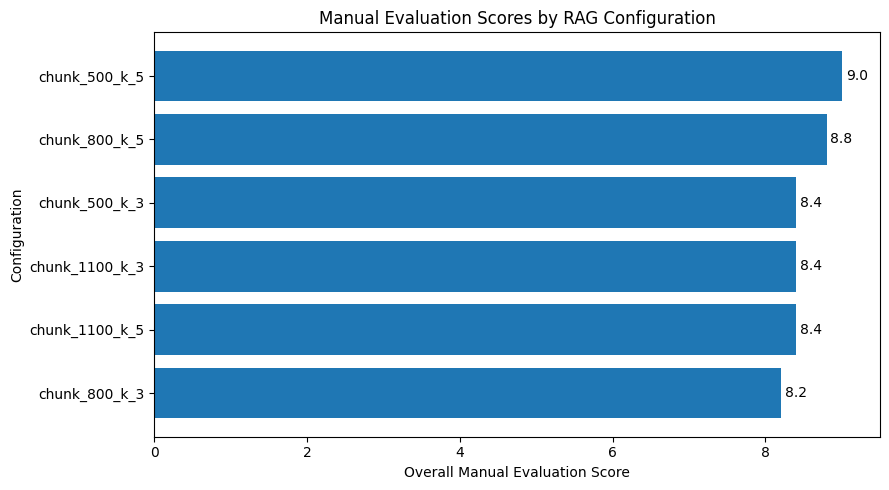

In [27]:
import matplotlib.pyplot as plt

plot_df = evaluation_summary.sort_values(
    "Overall Score",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["Configuration"],
    plot_df["Overall Score"]
)

plt.xlabel("Overall Manual Evaluation Score")
plt.ylabel("Configuration")
plt.title("Manual Evaluation Scores by RAG Configuration")
plt.xlim(0, 9.5)

for i, score in enumerate(plot_df["Overall Score"]):
    plt.text(
        score + 0.05,
        i,
        f"{score:.1f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### Interpretation

Among the six tested configurations, **500-character chunks with Top-K 5 achieved the highest manual evaluation score (9.0/9.0)** across relevance, completeness, and grounding.

Across the 500- and 800-character chunk sizes, Top-K 5 configurations scored higher overall than their Top-K 3 counterparts, mainly because the additional retrieved context improved answer completeness. For the 1100-character chunk size, Top-K 3 and Top-K 5 achieved the same overall score of 8.4, indicating that retrieving more large chunks did not improve downstream answer quality in this case.

However, increasing Top-K did not guarantee retrieval of the most relevant evidence. In the **Consumer Trends** question, some larger-chunk configurations failed to retrieve the key evidence on changes in consumer spending habits and brand loyalty, even with Top-K 5.

These results suggest that RAG performance depends on the interaction between **chunk size and retrieval depth**, rather than either parameter alone. For this report and evaluation set, **500-character chunks with Top-K 5 were selected as the final configuration**.

### Retrieval-Level Evaluation

The previous manual evaluation measures the quality of the generated answers. To evaluate the retriever separately, retrieved chunks were also assessed for whether they contained information relevant to each business question.

Each retrieved chunk was manually labeled as:

- **1 — Relevant:** Contains information that directly helps answer the question.
- **0 — Not Relevant:** Does not materially help answer the question.

For each configuration, the **Relevant Chunk Rate** is calculated as:

**Relevant Chunk Rate = Relevant Retrieved Chunks / Total Retrieved Chunks**

This metric helps distinguish retrieval quality from downstream answer-generation quality.

In [28]:
retrieval_eval_rows = []

for config_name, config_results in experiment_results.items():

    for category, result in config_results.items():

        for chunk_id, doc in enumerate(
            result["retrieved_docs"],
            start=1
        ):

            page = doc.metadata.get("page", "N/A")

            if page != "N/A":
                page += 1

            retrieval_eval_rows.append({
                "Configuration": config_name,
                "Category": category,
                "Chunk": chunk_id,
                "Page": page,
                "Content": doc.page_content,
                "Relevant": None
            })

retrieval_eval_df = pd.DataFrame(retrieval_eval_rows)

In [29]:
retrieval_relevance_labels = {
    "Industry Challenges": {
        "chunk_500_k_3":  [1, 1, 0],
        "chunk_500_k_5":  [1, 1, 0, 1, 1],
        "chunk_800_k_3":  [1, 1, 1],
        "chunk_800_k_5":  [1, 1, 1, 0, 1],
        "chunk_1100_k_3": [1, 1, 0],
        "chunk_1100_k_5": [1, 1, 0, 1, 0],
    },

    "Tariff Impact": {
        "chunk_500_k_3":  [0, 0, 1],
        "chunk_500_k_5":  [0, 0, 1, 0, 0],
        "chunk_800_k_3":  [0, 1, 0],
        "chunk_800_k_5":  [0, 1, 0, 0, 1],
        "chunk_1100_k_3": [0, 1, 1],
        "chunk_1100_k_5": [0, 1, 1, 0, 1],
    },

    "Cost Pressure": {
        "chunk_500_k_3":  [1, 1, 0],
        "chunk_500_k_5":  [1, 1, 0, 1, 1],
        "chunk_800_k_3":  [1, 1, 1],
        "chunk_800_k_5":  [1, 1, 1, 1, 1],
        "chunk_1100_k_3": [1, 0, 1],
        "chunk_1100_k_5": [1, 0, 1, 0, 1],
    },

    "Consumer Trends": {
        "chunk_500_k_3":  [1, 0, 1],
        "chunk_500_k_5":  [1, 0, 1, 1, 1],
        "chunk_800_k_3":  [1, 1, 0],
        "chunk_800_k_5":  [1, 1, 0, 1, 1],
        "chunk_1100_k_3": [1, 1, 1],
        "chunk_1100_k_5": [1, 1, 1, 0, 0],
    },

    "Retail Strategies": {
        "chunk_500_k_3":  [1, 1, 1],
        "chunk_500_k_5":  [1, 1, 1, 1, 1],
        "chunk_800_k_3":  [1, 1, 1],
        "chunk_800_k_5":  [1, 1, 1, 1, 1],
        "chunk_1100_k_3": [1, 1, 1],
        "chunk_1100_k_5": [1, 1, 1, 1, 1],
    }
}

for category, config_labels in retrieval_relevance_labels.items():
    for config, labels in config_labels.items():

        mask = (
            (retrieval_eval_df["Category"] == category) &
            (retrieval_eval_df["Configuration"] == config)
        )

        retrieval_eval_df.loc[mask, "Relevant"] = labels

print("Unlabeled chunks:", retrieval_eval_df["Relevant"].isna().sum())

Unlabeled chunks: 0


In [30]:
category = "Tariff Impact"

for config_name in [
    "chunk_500_k_3",
    "chunk_500_k_5"
]:

    result = experiment_results[config_name][category]

    print("\n" + "=" * 80)
    print("CONFIGURATION:", config_name)
    print("QUESTION:", result["question"])

    labels = retrieval_relevance_labels[category][config_name]

    for i, (doc, label) in enumerate(
        zip(result["retrieved_docs"], labels),
        start=1
    ):
        page = doc.metadata.get("page", "N/A")

        if page != "N/A":
            page += 1

        print(
            f"\n--- Chunk {i} | Page {page} "
            f"| Current Label = {label} ---"
        )
        print(doc.page_content)


CONFIGURATION: chunk_500_k_3
QUESTION: How are tariffs affecting retailers and consumers?

--- Chunk 1 | Page 8 | Current Label = 0 ---
13.  Steve Kopack and J.J. McCorvey, “Target calls price hikes a ‘very last resort’ for offsetting tariffs as sales slump,”  NBC News, May 21, 2025.
14.  SGB Media, “Study: Why retailers risk loyalty with tariff-based price hikes.”
15.  Vidhi Choudhary, “This American spice importer introduced a ‘Tariff Sale’ to counter Trump tariffs,” Retail Brew, April 8, 2025.
16.  Alex Vuocolo, “TJ Maxx parent says dropping some product categories may be answer to tariffs,”  Retail Brew, May 27, 2025.

--- Chunk 2 | Page 8 | Current Label = 0 ---
8.  Connor Hart, “Costco to rely on advancing orders, production shifts to offset tariffs,”  Wall Street Journal, May 29, 2025.
9.  Liz Young, “Retailers bulk up inventories to blunt tariff impact,” Wall Street Journal, March 24, 2025.
10.  Lindsey Wilkinson, “Retailers plug in AI to optimize costs as economic pressures m

In [31]:
overall_retrieval_summary = (
    retrieval_eval_df
    .groupby("Configuration")
    .agg(
        Relevant_Chunks=("Relevant", "sum"),
        Total_Chunks=("Relevant", "count")
    )
    .reset_index()
)

overall_retrieval_summary["Relevant Chunk Rate"] = (
    overall_retrieval_summary["Relevant_Chunks"]
    / overall_retrieval_summary["Total_Chunks"]
)

overall_retrieval_summary["Relevant Chunk Rate (%)"] = (
    overall_retrieval_summary["Relevant Chunk Rate"] * 100
).round(1)

overall_retrieval_summary = (
    overall_retrieval_summary
    .sort_values("Relevant Chunk Rate", ascending=False)
    .reset_index(drop=True)
)

overall_retrieval_summary

,Configuration,Relevant_Chunks,Total_Chunks,Relevant Chunk Rate,Relevant Chunk Rate (%)
0,chunk_1100_k_3,12,15,0.8,80.0
1,chunk_800_k_3,12,15,0.8,80.0
2,chunk_800_k_5,20,25,0.8,80.0
3,chunk_500_k_5,18,25,0.72,72.0
4,chunk_1100_k_5,17,25,0.68,68.0
5,chunk_500_k_3,10,15,0.666667,66.666667


In [32]:
combined_summary = evaluation_summary.merge(
    overall_retrieval_summary[
        [
            "Configuration",
            "Relevant_Chunks",
            "Total_Chunks",
            "Relevant Chunk Rate (%)"
        ]
    ],
    on="Configuration",
    how="left"
)

combined_summary = combined_summary[
    [
        "Configuration",
        "Chunk Size",
        "Top K",
        "Relevance",
        "Completeness",
        "Grounding",
        "Overall Score",
        "Relevant_Chunks",
        "Total_Chunks",
        "Relevant Chunk Rate (%)"
    ]
]

combined_summary

,Configuration,Chunk Size,Top K,Relevance,Completeness,Grounding,Overall Score,Relevant_Chunks,Total_Chunks,Relevant Chunk Rate (%)
0,chunk_500_k_5,500,5,3.0,3.0,3.0,9.0,18,25,72.0
1,chunk_800_k_5,800,5,3.0,2.8,3.0,8.8,20,25,80.0
2,chunk_500_k_3,500,3,3.0,2.4,3.0,8.4,10,15,66.666667
3,chunk_1100_k_3,1100,3,3.0,2.4,3.0,8.4,12,15,80.0
4,chunk_1100_k_5,1100,5,2.8,2.8,2.8,8.4,17,25,68.0
5,chunk_800_k_3,800,3,3.0,2.2,3.0,8.2,12,15,80.0


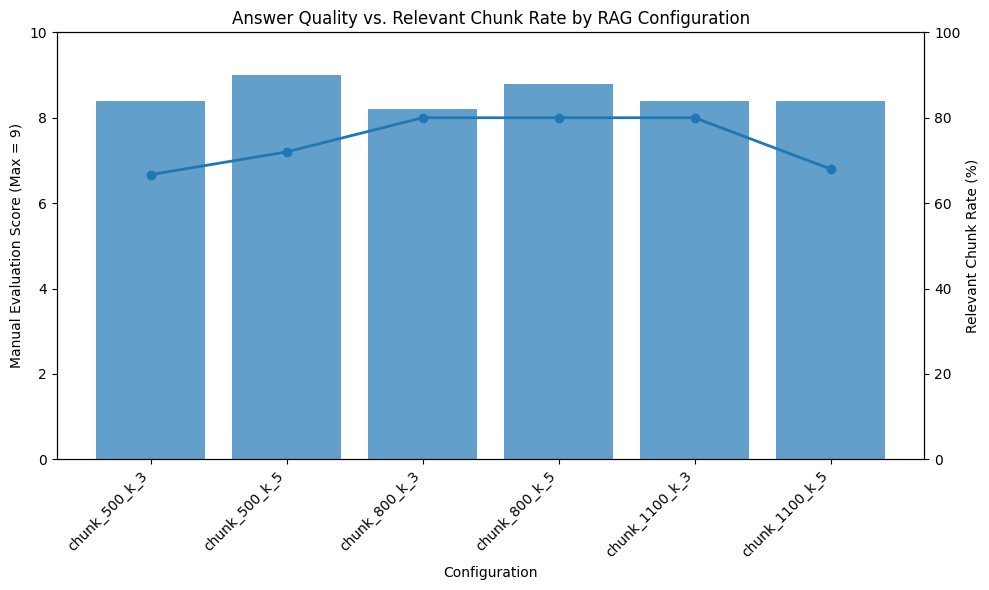

In [33]:
fig, ax1 = plt.subplots(figsize=(10, 6))

plot_order = [
    "chunk_500_k_3",
    "chunk_500_k_5",
    "chunk_800_k_3",
    "chunk_800_k_5",
    "chunk_1100_k_3",
    "chunk_1100_k_5"
]

plot_df = (
    combined_summary
    .set_index("Configuration")
    .loc[plot_order]
    .reset_index()
)

x = range(len(plot_df))

ax1.bar(
    x,
    plot_df["Overall Score"],
    alpha=0.7,
    label="Answer Quality Score"
)

ax1.set_ylabel("Manual Evaluation Score (Max = 9)")
ax1.set_xlabel("Configuration")
ax1.set_xticks(x)
ax1.set_xticklabels(
    plot_df["Configuration"],
    rotation=45,
    ha="right"
)
ax1.set_ylim(0, 10)

ax2 = ax1.twinx()

ax2.plot(
    x,
    plot_df["Relevant Chunk Rate (%)"],
    marker="o",
    linewidth=2,
    label="Relevant Chunk Rate"
)

ax2.set_ylabel("Relevant Chunk Rate (%)")
ax2.set_ylim(0, 100)

ax1.set_title(
    "Answer Quality vs. Relevant Chunk Rate by RAG Configuration"
)

fig.tight_layout()
plt.show()

### Retrieval vs. Answer Quality

The retrieval-level evaluation reveals that retrieval precision and final answer quality are related but distinct dimensions of RAG performance.

The **500-character / Top-K 5** configuration achieved the highest manual answer-quality score (**9.0/9.0**) while retrieving **72% relevant chunks**. In comparison, the **800-character / Top-K 5** configuration achieved a higher Relevant Chunk Rate (**80%**) but a slightly lower answer-quality score (**8.8/9.0**).

This indicates that a higher proportion of relevant retrieved chunks does not necessarily produce a more complete final answer. Some retrieved chunks may be broadly relevant without containing the specific evidence required to answer a question fully. Conversely, a configuration can tolerate some retrieval noise when the retrieved context still contains the key evidence needed by the language model.

Top-K also showed a trade-off between **evidence coverage and retrieval precision**. Retrieving five chunks generally improved answer completeness, but in some cases introduced non-substantive content such as report covers or reference sections.

Therefore, Relevant Chunk Rate is treated as a **retrieval precision-oriented diagnostic metric**, rather than a standalone measure of overall RAG quality. Based primarily on downstream answer relevance, completeness, and grounding, **500-character chunks with Top-K 5 were selected as the final configuration for this report and evaluation set**.

### Experiment 1B: Document Cleaning

Inspection of the retrieved chunks showed that some low-value document sections were being retrieved despite providing little substantive evidence for the business questions.

In particular, the cover page, table of contents, contact page, endnotes, and legal boilerplate contained keywords that could match user queries. The endnotes page was especially noticeable in tariff-related retrieval, where citation text occupied several Top-K positions.

To test whether simple document preprocessing could improve retrieval quality, a cleaned document set was created by retaining only pages 3–6, which contain the substantive introduction, retail trends, and conclusion.

The cleaned RAG pipeline uses the highest-scoring configuration among the six tested settings identified in Experiment 1.

- Chunk size: 500 characters
- Chunk overlap: 150 characters
- Top-K: 5
- Same embedding model
- Same language model

This keeps the retrieval configuration and models constant, allowing the experiment to focus on the effect of document cleaning.

Because the cleaning rule was defined after inspecting the structure of this specific report, the result should be interpreted as a report-specific preprocessing experiment rather than an independently validated document-cleaning benchmark.

In [34]:
# Keep only substantive report pages (PDF pages 3–6)
clean_documents = documents[2:6]

print("Original document pages:", len(documents))
print("Cleaned document pages:", len(clean_documents))


clean_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=150
)

clean_chunks = clean_splitter.split_documents(
    clean_documents
)

clean_vectorstore = FAISS.from_documents(
    clean_chunks,
    embeddings
)

clean_retriever = clean_vectorstore.as_retriever(
    search_kwargs={"k": 5}
)

print("Cleaned retriever created successfully.")
print("Number of cleaned chunks:", len(clean_chunks))

Original document pages: 9
Cleaned document pages: 4
Cleaned retriever created successfully.
Number of cleaned chunks: 27


In [35]:
clean_comparison = {}

original_retriever = rag_experiments["chunk_500_k_5"]["retriever"]

for category, question in business_questions.items():

    original_docs = original_retriever.invoke(question)
    cleaned_docs = clean_retriever.invoke(question)

    clean_comparison[category] = {
        "question": question,
        "original_docs": original_docs,
        "cleaned_docs": cleaned_docs
    }

print("Retrieval comparisons generated:", len(clean_comparison))

Retrieval comparisons generated: 5


In [36]:
low_value_pages = {1, 2, 7, 8, 9}

comparison_rows = []

for category, result in clean_comparison.items():

    original_pages = []
    cleaned_pages = []

    for doc in result["original_docs"]:
        page = doc.metadata.get("page", "N/A")

        if page != "N/A":
            page += 1

        original_pages.append(page)

    for doc in result["cleaned_docs"]:
        page = doc.metadata.get("page", "N/A")

        if page != "N/A":
            page += 1

        cleaned_pages.append(page)

    original_low_value = sum(
        page in low_value_pages
        for page in original_pages
    )

    cleaned_low_value = sum(
        page in low_value_pages
        for page in cleaned_pages
    )

    comparison_rows.append({
        "Category": category,
        "Original Low-Value Chunks": original_low_value,
        "Original Low-Value Rate": original_low_value / len(original_pages),
        "Cleaned Low-Value Chunks": cleaned_low_value,
        "Cleaned Low-Value Rate": cleaned_low_value / len(cleaned_pages)
    })

cleaning_df = pd.DataFrame(comparison_rows)
cleaning_df


,Category,Original Low-Value Chunks,Original Low-Value Rate,Cleaned Low-Value Chunks,Cleaned Low-Value Rate
0,Industry Challenges,1,0.2,0,0.0
1,Tariff Impact,4,0.8,0,0.0
2,Cost Pressure,1,0.2,0,0.0
3,Consumer Trends,0,0.0,0,0.0
4,Retail Strategies,0,0.0,0,0.0


In [37]:
print(
    "Original average low-value retrieval rate:",
    f"{cleaning_df['Original Low-Value Rate'].mean():.1%}"
)

print(
    "Cleaned average low-value retrieval rate:",
    f"{cleaning_df['Cleaned Low-Value Rate'].mean():.1%}"
)

Original average low-value retrieval rate: 24.0%
Cleaned average low-value retrieval rate: 0.0%


In [38]:
clean_answer_results = {}

for category, question in business_questions.items():

    # Retrieve supporting chunks once
    retrieved_docs = clean_retriever.invoke(question)

    # Format retrieved context
    context = format_docs(retrieved_docs)

    # Generate answer using the same prompt and LLM
    response = rag_chain.invoke({
        "context": context,
        "question": question
    })

    clean_answer_results[category] = {
        "question": question,
        "response": response,
        "retrieved_docs": retrieved_docs
    }

print("Cleaned RAG answers generated:", len(clean_answer_results))

Cleaned RAG answers generated: 5


### Cleaned RAG Answer Evaluation

The cleaned RAG responses were manually evaluated using the same relevance, completeness, and grounding rubric applied in Experiment 1. The cleaned configuration was assessed across the same five business questions to determine whether document cleaning reduced retrieval noise without degrading downstream answer quality.

In [39]:
category = "Consumer Trends"

result = clean_answer_results[category]

print("=" * 80)
print("CATEGORY:", category)

print("\nQUESTION:")
print(result["question"])

print("\nRESPONSE:")
print(result["response"])

print("\nRETRIEVED EVIDENCE:")

for i, doc in enumerate(result["retrieved_docs"], start=1):

    page = doc.metadata.get("page", "N/A")

    if page != "N/A":
        page += 1

    print(f"\n--- Chunk {i} | Page {page} ---")
    print(doc.page_content)

CATEGORY: Consumer Trends

QUESTION:
How are consumers changing their shopping behavior in response to price increases?

RESPONSE:
Consumers are shifting their spending habits in response to any price increase. They are also favoring brands that absorb tariff-related costs, with 79% pledging loyalty to such brands.

RETRIEVED EVIDENCE:

--- Chunk 1 | Page 3 ---
anticipated changes: 30%1 of shoppers surveyed say that any 
price increase would cause them to shift spending habits, 
and 79%2 have pledged loyalty to brands that fully absorb the 
potential cost of tariffs. To stay competitive, some companies 
are prioritizing two key strategies: investing in technology 
to modernize and increase the agility of their supply chains, 
and adopting consumer-focused approaches in pricing, 
promotion, and assortment planning. By combining supply

--- Chunk 2 | Page 5 ---
have great value on the goods that we put out there.”17 
Even so, other retailers have seen successes too. Target 
cited that it

In [40]:
category = "Tariff Impact"

result = clean_answer_results[category]

print("=" * 80)
print("CATEGORY:", category)

print("\nQUESTION:")
print(result["question"])

print("\nRESPONSE:")
print(result["response"])

print("\nRETRIEVED EVIDENCE:")

for i, doc in enumerate(result["retrieved_docs"], start=1):

    page = doc.metadata.get("page", "N/A")

    if page != "N/A":
        page += 1

    print(f"\n--- Chunk {i} | Page {page} ---")
    print(doc.page_content)

CATEGORY: Tariff Impact

QUESTION:
How are tariffs affecting retailers and consumers?

RESPONSE:
Tariffs are increasing retailers’ costs, squeezing profit margins, and adding complexity to global supply chains. Retailers are responding with more than simply raising prices or absorbing costs: they are modernizing supply chains, adjusting pricing, promotions, loyalty programs, and product assortments, and sometimes removing products from shelves.

Consumers are sensitive to tariff-related price increases: 30% of surveyed shoppers said any increase would change their spending habits, while 79% pledged loyalty to brands that fully absorb tariff costs. Retailers therefore view price increases as a last resort and aim to communicate changes clearly and offer more value through promotions and loyalty programs.

RETRIEVED EVIDENCE:

--- Chunk 1 | Page 5 ---
Depot’s executive vice president of merchandising 
announced that the company intends to “maintain 
pricing across our portfolio,” though 

In [41]:
category = "Industry Challenges"

result = clean_answer_results[category]

print("=" * 80)
print("CATEGORY:", category)

print("\nQUESTION:")
print(result["question"])

print("\nRESPONSE:")
print(result["response"])

print("\nRETRIEVED EVIDENCE:")

for i, doc in enumerate(result["retrieved_docs"], start=1):

    page = doc.metadata.get("page", "N/A")

    if page != "N/A":
        page += 1

    print(f"\n--- Chunk {i} | Page {page} ---")
    print(doc.page_content)

CATEGORY: Industry Challenges

QUESTION:
What are the main challenges facing the retail industry?

RESPONSE:
The main challenges facing the retail industry are:

- New tariffs and trade uncertainty
- Rising costs and pressure on profit margins
- Increasing complexity and risk across global supply chains
- Consumer concern about price increases and shifts in spending habits
- Balancing inventory levels with uncertain demand, including excess-inventory risk
- Accurately forecasting changes in consumer demand while preserving customer trust and value

RETRIEVED EVIDENCE:

--- Chunk 1 | Page 5 ---
alternatives.
 • Lean on loyalty programs and points to enhance 
customer experience and encourage engagement.
Product assortment restructuring
Resilient assortment planning has emerged as a strategy 
for some retailers such as TJX Companies, owner of 
discount department store chains TJ Maxx, Marshalls, and 
HomeGoods. CEO Ernie Herrman expressed confidence in 
managing possible impacts from tar

In [42]:
clean_scores = {
    "Industry Challenges": [3, 3, 3],
    "Tariff Impact": [3, 3, 3],
    "Cost Pressure": [3, 3, 3],
    "Consumer Trends": [3, 3, 3],
    "Retail Strategies": [3, 3, 3]
}

clean_rationales = {
    "Industry Challenges":
        "The answer directly identifies the major report-supported challenges, including tariffs, "
        "cost and margin pressure, supply-chain complexity, consumer price sensitivity, inventory risk, "
        "and demand forecasting. The retrieved evidence supports these claims.",

    "Tariff Impact":
        "The answer comprehensively explains tariff effects on retailers and consumers, including higher costs, "
        "margin pressure, supply-chain complexity, selective pricing, cost absorption, assortment changes, "
        "and consumer spending responses. The claims are supported by the retrieved evidence.",

    "Cost Pressure":
        "The answer identifies the major cost pressures described in the report, including tariffs, tightening margins, "
        "price uncertainty, and supply-chain complexity, while explaining retailer responses. "
        "The claims are supported by the retrieved evidence.",

    "Consumer Trends":
        "The answer directly captures the key consumer findings: 30% of surveyed shoppers would change spending habits "
        "after a price increase, while 79% expressed loyalty to brands that absorb tariff-related costs. "
        "Both claims are directly supported by the retrieved evidence.",

    "Retail Strategies":
        "The answer covers the major report-supported retailer responses, including selective pricing, cost absorption, "
        "promotions, loyalty programs, assortment changes, sourcing adjustments, and supply-chain strategies. "
        "The retrieved evidence supports the response."
}

clean_score_rows = []

for category, scores in clean_scores.items():
    clean_score_rows.append({
        "Category": category,
        "Relevance": scores[0],
        "Completeness": scores[1],
        "Grounding": scores[2],
        "Evaluation Rationale": clean_rationales[category]
    })

clean_scores_df = pd.DataFrame(clean_score_rows)

clean_scores_df

,Category,Relevance,Completeness,Grounding,Evaluation Rationale
0,Industry Challenges,3,3,3,The answer directly identifies the major repor...
1,Tariff Impact,3,3,3,The answer comprehensively explains tariff eff...
2,Cost Pressure,3,3,3,The answer identifies the major cost pressures...
3,Consumer Trends,3,3,3,The answer directly captures the key consumer ...
4,Retail Strategies,3,3,3,The answer covers the major report-supported r...


In [43]:
clean_avg_scores = clean_scores_df[
    ["Relevance", "Completeness", "Grounding"]
].mean()

clean_overall_score = clean_avg_scores.sum()

print("Cleaned RAG Average Scores:")
print(clean_avg_scores.round(2))

print(
    "\nCleaned RAG Overall Answer Quality:",
    round(clean_overall_score, 2),
    "/ 9.0"
)

Cleaned RAG Average Scores:
Relevance       3.0
Completeness    3.0
Grounding       3.0
dtype: float64

Cleaned RAG Overall Answer Quality: 9.0 / 9.0


### Document Cleaning Findings

The document-cleaning experiment showed that non-substantive document sections can occupy limited retrieval positions and introduce noise into the retrieved context.

Using the original document, an average of **24.0% of the Top-5 retrieved chunks** across the five business questions came from low-value pages, including the cover page, table of contents, contact information, endnotes, and legal boilerplate. After retaining only the substantive report pages (Pages 3–6), the average low-value retrieval rate decreased from **24.0% to 0.0%**.

The effect was particularly visible for the **Tariff Impact** question. In the original pipeline, four of the five retrieved chunks came from the endnotes page because citation text contained tariff-related terms. After document cleaning, these limited Top-K positions were instead occupied by substantive report content related to tariff impacts, pricing, consumer responses, and retailer strategies.

To determine whether removing these sections affected downstream performance, the cleaned RAG pipeline was evaluated using the same relevance, completeness, and grounding rubric applied in Experiment 1. It achieved an overall answer-quality score of **9.0/9.0**, matching the highest-scoring original configuration.

These results suggest that, for this document and evaluation set, document cleaning **reduced retrieval noise without degrading downstream answer quality**. The experiment highlights the value of document preprocessing in RAG pipelines when non-substantive sections contain query-related keywords that can compete with useful evidence for a limited number of retrieval positions.

### Original vs Cleaned RAG

| Metric | Original RAG | Cleaned RAG |
|---|---:|---:|
| Chunk Size | 500 | 500 |
| Chunk Overlap | 150 | 150 |
| Top-K | 5 | 5 |
| Avg. Relevance | 3.0 | 3.0 |
| Avg. Completeness | 3.0 | 3.0 |
| Avg. Grounding | 3.0 | 3.0 |
| Overall Answer Quality | 9.0 / 9.0 | 9.0 / 9.0 |
| Avg. Low-Value Retrieval Rate | 24.0% | **0.0%** |

## 12. Experiment 2: Plain LLM vs. RAG

This experiment compares a baseline language model with the final RAG system using the same business question.

The baseline LLM answers using only its existing model knowledge, without access to the retail report. In contrast, the final RAG pipeline retrieves relevant chunks from the cleaned report and provides them as context for a document-grounded response.

The goal is to illustrate how retrieval affects answer specificity, grounding, and source traceability for a representative business question.


In [44]:
comparison_question = "What are the main challenges facing the retail industry?"

plain_prompt = ChatPromptTemplate.from_template(
    """Answer the following business question clearly and concisely.

Question:
{question}
"""
)

plain_chain = (
    plain_prompt
    | llm
    | StrOutputParser()
)

plain_response = plain_chain.invoke({
    "question": comparison_question
})

print("Question:")
print(comparison_question)

print("\nPlain LLM Answer:")
print(plain_response)

Question:
What are the main challenges facing the retail industry?

Plain LLM Answer:
The retail industry faces several major challenges:

- **Changing consumer behavior:** Customers expect convenience, personalization, fast delivery, seamless returns, and consistent online and in-store experiences.
- **Economic pressure:** Inflation, interest rates, and uncertain consumer spending make demand harder to predict while raising operating costs.
- **Margin compression:** Price competition, promotions, shipping expenses, returns, and higher labor and inventory costs reduce profitability.
- **Supply-chain volatility:** Disruptions, long lead times, geopolitical risks, and demand forecasting errors can cause shortages or excess inventory.
- **Omnichannel execution:** Retailers must integrate stores, websites, apps, marketplaces, payments, fulfillment, and customer data effectively.
- **Intense competition:** E-commerce platforms, direct-to-consumer brands, discount retailers, and global marke

In [45]:
# Retrieve supporting chunks from the cleaned report
rag_sources = clean_retriever.invoke(comparison_question)

# Format retrieved context
rag_context = format_docs(rag_sources)

# Generate document-grounded RAG answer
rag_response = rag_chain.invoke({
    "context": rag_context,
    "question": comparison_question
})

print("\nRAG Answer:")
print(rag_response)

source_pages = []

for doc in rag_sources:
    page = doc.metadata.get("page", "N/A")

    if page != "N/A":
        page += 1

    if page not in source_pages:
        source_pages.append(page)

print("\nSource Pages:")
print(", ".join(map(str, source_pages)))


RAG Answer:
The main challenges facing the retail industry include:

- New tariffs and potentially higher costs
- Pressure on profit margins
- Increasing complexity across global supply chains
- Consumer concern over price increases and shifts in spending habits
- Supply-chain sourcing and production risks
- Balancing inventory levels with uncertain demand, including the risk of excess inventory
- Accurately anticipating changes in consumer demand while preserving customer trust and value

Source Pages:
5, 3, 4


### Comparison Findings

The plain LLM and the final cleaned RAG pipeline were tested using the same business question. The RAG pipeline used the best-performing retrieval configuration identified in Experiment 1: **500-character chunks, 150-character overlap, and Top-K=5**.

The **plain LLM** produced a broad industry-level answer based on general model knowledge. It identified challenges such as changing consumer behavior, economic pressure, intense competition, margin compression, inventory and supply-chain management, workforce challenges, technology transformation, cybersecurity and privacy, theft and fraud, and sustainability and regulation.

The **RAG system**, in contrast, produced a more report-specific answer. It focused on tariffs, cost and margin pressure, global supply-chain complexity, consumer price sensitivity, demand uncertainty, excess inventory risk, demand forecasting, and supply-chain agility — themes directly related to the selected retail report.

The RAG pipeline also retrieved five document chunks, and their source-page metadata was displayed alongside the generated answer, providing greater traceability to the underlying business document.

### Key Takeaway

The experiment highlights an important distinction between general-purpose LLM responses and retrieval-augmented generation.

The plain LLM provided a broader overview of retail-industry challenges, but its answer was not tied to the selected report. The RAG system produced a narrower but more document-specific response supported by retrieved evidence.

For this project, RAG is therefore more suitable when the objective is to generate business insights from a specific source document with greater grounding and source traceability.

Because this comparison uses a single representative question, it should be interpreted as an illustrative case study rather than a comprehensive benchmark of plain LLM and RAG performance.

## 13. Key Findings

The project produced several findings from both the retail report analysis and the RAG experiments.

### Business Findings

The RAG analysis identified several important themes from the retail report:

- **Tariff uncertainty:** New tariffs are creating uncertainty around costs and profit margins.
- **Supply-chain complexity:** Retailers are facing increasing complexity across global supply chains.
- **Consumer price sensitivity:** Price increases may cause consumers to adjust their spending behavior.
- **Consumer trust:** Retailers need to manage cost pressures while maintaining customer trust and loyalty.
- **Retail strategies:** Retailers are using strategies such as selective pricing, product assortment changes, sourcing adjustments, promotions, and loyalty programs to respond to cost pressures.

### RAG Evaluation Findings

The retrieval experiments showed that RAG performance was influenced by both retrieval configuration and document preprocessing.

- The **500-character / Top-K 5 configuration achieved the highest overall evaluation score of 9.0/9.0** across the five business questions.
- Increasing **Top-K from 3 to 5 generally improved or maintained answer completeness**, although the effect depended on chunk size and the specific evidence retrieved.
- The **800-character / Top-K 5 configuration ranked second with an overall score of 8.8**, while the **1100-character / Top-K 5 configuration achieved 8.4**.
- Larger chunks did not consistently produce better results. The 500-character chunks performed particularly well when combined with Top-K 5.
- The **Consumer Trends** question showed that retrieving more or larger context does not necessarily guarantee that the most decision-relevant evidence is captured or correctly used by the language model, highlighting the importance of both retrieval quality and downstream context utilization.
- Document inspection showed that non-substantive sections, such as the cover page, table of contents, endnotes, contact information, and legal boilerplate, could occupy limited retrieval positions when they contained query-related keywords.
- After preprocessing the selected Deloitte report to retain substantive content pages, the **average low-value retrieval rate decreased from 24.0% to 0.0%**, while the cleaned RAG pipeline maintained an overall answer-quality score of **9.0/9.0**.

Based on this small-scale evaluation, **500-character chunks with Top-K 5 were selected as the best-performing retrieval configuration among those tested**. For the selected Deloitte report, document preprocessing further improved retrieval quality by removing low-value content without reducing evaluated answer quality.

### Business Implications and Potential Actions

The following table translates report-grounded findings into potential business implications and analyst-proposed actions. The proposed actions represent analytical recommendations derived from the report findings rather than direct recommendations quoted from the source document:

| Report-Grounded Finding | Business Implication | Analyst-Proposed Action |
|---|---|---|
| Tariff uncertainty | Higher import costs may create pressure on margins and pricing decisions. | Review sourcing options and consider selective pricing adjustments rather than broad price increases. |
| Supply-chain complexity | Greater uncertainty may increase inventory and sourcing risks. | Diversify sourcing and improve supply-chain visibility and demand forecasting. |
| Consumer price sensitivity | Price increases may cause consumers to change spending behavior. | Use segmented pricing, promotions, and value-focused product options to reduce customer impact. |
| Consumer trust | Poorly managed or communicated price increases may weaken customer trust and loyalty. | Clearly communicate necessary price changes and use loyalty programs to reinforce customer value. |
| Inventory risk | Front-loading orders may create excess inventory if demand weakens. | Improve demand forecasting and monitor inventory levels before making large purchasing commitments. |


## 14. Limitations & Future Improvements

Although the RAG system produced useful and generally well-grounded responses within the selected report and evaluation set, several limitations remain.

### Limitations

- **Single-document scope:** The system was tested using one retail industry report, so the findings may not generalize to other documents, industries, or document structures.
- **Limited evaluation set:** The retrieval experiment used five business questions. A larger and more diverse evaluation set would provide stronger evidence about configuration performance.
- **Manual evaluation:** Relevance, completeness, grounding, and retrieved-chunk relevance were evaluated manually, which introduces evaluator subjectivity.
- **Limited configuration search:** The experiment compared six combinations of three chunk sizes (500, 800, and 1100 characters) and two Top-K values (3 and 5), while keeping chunk overlap fixed at 150 characters. Other chunk sizes, overlap values, and retrieval parameters may produce different results.
- **Retrieval and context-utilization variability:** Retrieval results varied across chunk sizes and Top-K settings. In addition, retrieving relevant evidence did not always guarantee that the language model would use that evidence correctly or completely in the final answer.
- **Report-specific preprocessing:** The document-cleaning experiment manually retained Pages 3–6 of the selected Deloitte report based on inspection of its structure. This approach is report-specific and may not generalize to documents with different layouts or content organization.
- **Retrieval metric limitations:** Relevant Chunk Rate provides a useful precision-oriented diagnostic, but it does not measure whether all important evidence was retrieved or how highly the most useful evidence was ranked.
- **Small-scale comparison:** The Plain LLM vs. RAG experiment used one representative business question, so it illustrates the difference between the two approaches rather than providing a comprehensive benchmark.

### Future Improvements

Future versions of the project could:

- Test the RAG pipeline across multiple retail and consumer-industry reports.
- Expand the evaluation set with more business questions covering different levels of difficulty and specificity.
- Introduce automated or LLM-assisted evaluation alongside manual scoring.
- Test additional retrieval parameters, including chunk overlap and a wider range of Top-K values.
- Compare alternative embedding models and retrieval methods, such as hybrid semantic and keyword search.
- Expand retrieval-quality evaluation beyond Relevant Chunk Rate by introducing metrics such as Precision@K, Recall@K, or nDCG, supported by a larger relevance-labeled evaluation set.
- Evaluate not only whether relevant evidence is retrieved, but also whether the language model correctly uses that evidence in the generated answer.
- Develop more robust document preprocessing rules to automatically identify and remove low-value sections, such as cover pages, tables of contents, references, contact pages, and legal boilerplate across different report formats.

## 15. Streamlit Application

A Streamlit application was developed to provide an interactive interface for the RAG system.

The application allows users to:

- Upload a retail industry report in PDF format.
- Process and split the uploaded document into text chunks.
- Create embeddings and store them in a FAISS vector store.
- Ask business-related questions about the uploaded report.
- Generate document-grounded answers using RAG.
- View the retrieved source chunks and their page numbers for each answer.

The application uses the best-performing retrieval configuration identified in the notebook evaluation: **500-character chunks with 150-character overlap and Top-K set to 5**. Unlike the report-specific document-cleaning experiment, the application processes the full uploaded PDF so that it can support reports with different page structures. Automatic identification and removal of low-value sections is left as a future improvement. Streamlit resource caching is used to reduce unnecessary rebuilding of the embeddings and FAISS vector store when the same uploaded document and API configuration are reused.


In [46]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 68.3 MB/s eta 0:00:00


In [47]:
%%writefile app.py

import os
import tempfile
import streamlit as st

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate


CHUNK_SIZE = 500
CHUNK_OVERLAP = 150
TOP_K = 5
EMBEDDING_MODEL = "text-embedding-3-large"
LLM_MODEL = "gpt-5.6"


st.set_page_config(
    page_title="AI-Powered Retail Report Analysis",
    page_icon="📊",
    layout="wide"
)

st.title("AI-Powered Retail Report Analysis")

st.write(
    "Upload a retail industry report and ask business questions "
    "using Retrieval-Augmented Generation (RAG)."
)

st.caption(
    f"Retrieval configuration: {CHUNK_SIZE}-character chunks, "
    f"{CHUNK_OVERLAP}-character overlap, Top-K = {TOP_K}."
)


# OpenAI API Key
api_key = st.sidebar.text_input(
    "OpenAI API Key",
    type="password"
)

if not api_key:
    st.sidebar.info(
        "Enter your OpenAI API key to analyze a report."
    )


@st.cache_resource
def build_rag_components(file_bytes, api_key):

    pdf_path = None

    try:
        with tempfile.NamedTemporaryFile(
            delete=False,
            suffix=".pdf"
        ) as temp_file:
            temp_file.write(file_bytes)
            pdf_path = temp_file.name

        loader = PyPDFLoader(pdf_path)
        documents = loader.load()

    finally:
        if pdf_path and os.path.exists(pdf_path):
            os.remove(pdf_path)

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE,
        chunk_overlap=CHUNK_OVERLAP
    )

    chunks = text_splitter.split_documents(documents)

    embeddings = OpenAIEmbeddings(
        model=EMBEDDING_MODEL,
        api_key=api_key
    )

    vectorstore = FAISS.from_documents(
        chunks,
        embeddings
    )

    retriever = vectorstore.as_retriever(
        search_kwargs={"k": TOP_K}
    )

    return documents, chunks, retriever


# Upload PDF
uploaded_file = st.file_uploader(
    "Upload Retail Report",
    type="pdf"
)


if uploaded_file is not None and api_key:

    file_bytes = uploaded_file.getvalue()

    try:
        documents, chunks, retriever = build_rag_components(
            file_bytes,
            api_key
        )

        llm = ChatOpenAI(
            model=LLM_MODEL,
            api_key=api_key
        )

        prompt = ChatPromptTemplate.from_template(
            """Use the following retrieved context to answer the question.

Answer only from the provided context.
If the answer is not in the context, say you do not know.

Context:
{context}

Question:
{question}
"""
        )

        st.success(
            f"Report processed successfully: "
            f"{len(documents)} pages and {len(chunks)} chunks."
        )

        question = st.text_input(
            "Ask a Business Question",
            placeholder="What are the main challenges facing the retail industry?"
        )

        if st.button("Analyze Report"):

            if question:

                with st.spinner("Analyzing the report..."):

                    # Retrieve only once
                    source_documents = retriever.invoke(question)

                    context = "\n\n".join(
                        doc.page_content
                        for doc in source_documents
                    )

                    formatted_prompt = prompt.invoke({
                        "context": context,
                        "question": question
                    })

                    response = llm.invoke(
                        formatted_prompt
                    ).content

                st.subheader("AI Answer")
                st.write(response)

                st.subheader("Supporting Sources")

                for i, doc in enumerate(
                    source_documents,
                    start=1
                ):

                    page = doc.metadata.get(
                        "page",
                        "N/A"
                    )

                    if page != "N/A":
                        page += 1

                    with st.expander(
                        f"Source {i} — Page {page}"
                    ):
                        st.write(doc.page_content)

            else:
                st.warning(
                    "Please enter a business question."
                )

    except Exception as e:
        st.error(
            f"An error occurred while processing the report: {e}"
        )


elif uploaded_file is not None and not api_key:

    st.warning(
        "Please enter your OpenAI API key in the sidebar."
    )

Writing app.py


### Running the Streamlit App in Google Colab

The following commands launch the Streamlit application inside the Google Colab environment for demonstration purposes. The CORS and XSRF settings are disabled only to support iframe-based display in Colab and are not intended as production deployment settings.

In [48]:
!pkill -f streamlit

!streamlit run app.py \
    --server.port=8501 \
    --server.enableCORS=false \
    --server.enableXsrfProtection=false \
    --server.headless=true \
    > /content/logs.txt 2>&1 &

print("Streamlit restarted.")

Streamlit restarted.


In [49]:
import time
from google.colab import output

time.sleep(5)

output.serve_kernel_port_as_iframe(
    8501,
    width="100%",
    height=800
)

<IPython.core.display.Javascript object>

## 16. GitHub Repository

The final project is organized for reproducibility, documentation, and portfolio presentation. The repository includes the RAG analysis notebook, Streamlit application, project dependencies, and supporting documentation.

In [50]:
%%writefile requirements.txt

langchain==1.3.15
langchain-core==1.5.6
langchain-community==0.4.2
langchain-openai==1.5.2
langchain-text-splitters==1.1.2
openai==2.54.0
pypdf==6.16.1
faiss-cpu==1.15.0
pandas==2.2.3
streamlit==1.61.1

Writing requirements.txt


In [51]:
%%writefile .gitignore

.env
.env.*
__pycache__/
*.pyc
.DS_Store
logs.txt

Writing .gitignore


In [52]:
%%writefile README.md
# AI-Powered Retail Report Analysis Using RAG

An AI-powered retail report analysis system that uses Retrieval-Augmented Generation (RAG) to answer business questions based on information retrieved from a retail industry report.

## Project Overview

This project demonstrates how Retrieval-Augmented Generation (RAG) can be applied to business document analysis.

The system processes a retail industry report, converts the document into searchable vector embeddings, retrieves relevant information based on a user's question, and generates an answer grounded in the retrieved report content.

In addition to building the RAG pipeline, the project evaluates different retrieval configurations by varying text chunk size and Top-K retrieval, examines the effect of document preprocessing on retrieval quality, and compares RAG-generated answers with responses from a plain large language model.

## Business Problem

Retail industry reports contain valuable information about market trends, consumer behavior, cost pressures, supply-chain challenges, and business strategies. However, manually reviewing reports to locate relevant insights can be time-consuming.

This project explores whether a RAG-based system can help users retrieve relevant information and answer business questions directly from an industry report.

## Project Objectives

- Build an end-to-end RAG pipeline for retail report analysis.
- Retrieve relevant document sections using semantic similarity.
- Generate answers grounded in the source report.
- Evaluate how different chunk sizes and Top-K retrieval settings affect RAG performance.
- Evaluate retrieval quality using manually labeled retrieved chunks.
- Examine whether document preprocessing can reduce retrieval noise.
- Compare a plain LLM with a RAG-based approach.
- Identify key retail business insights from the report.
- Develop an interactive Streamlit application for report analysis.

## Technologies Used

- Python
- LangChain
- OpenAI API
- GPT-5.6
- OpenAI text-embedding-3-large
- FAISS
- PyPDF
- Pandas
- Streamlit
- Google Colab

Writing README.md


In [53]:
%%writefile -a README.md

## RAG Architecture

The project follows the following Retrieval-Augmented Generation workflow:

PDF Report
↓
Document Loading
↓
Text Splitting
↓
OpenAI Embeddings
↓
FAISS Vector Store
↓
User Question
↓
Similarity Retrieval (Top-K = 5)
↓
Relevant Document Chunks
↓
Prompt + Retrieved Context
↓
Large Language Model
↓
Grounded Answer + Supporting Sources

The retail report is first loaded and divided into smaller text chunks. OpenAI embeddings are then used to convert the chunks into vector representations, which are stored in a FAISS vector store.

When a user asks a business question, similarity retrieval identifies the top relevant document chunks. These chunks are provided to the language model as context for generating a report-grounded answer.

## Methodology

### 1. Document Loading

The retail industry report was loaded from PDF format using PyPDFLoader.

### 2. Text Splitting

The document was divided into smaller text chunks using RecursiveCharacterTextSplitter.

The final retrieval configuration uses:

- Chunk size: 500 characters
- Chunk overlap: 150 characters
- Top-K retrieval: 5

### 3. Embeddings

OpenAI Embeddings using `text-embedding-3-large` were used to transform the document chunks into vector representations.

### 4. Vector Store

The embeddings were stored in a FAISS vector store for efficient similarity search.

### 5. Retrieval

The final retriever returns the top 5 semantically similar chunks for each business question.

### 6. RAG Question Answering

The retrieved chunks are passed to the language model as context. The system generates an answer grounded in the retrieved content, while the retrieved chunks and their source-page metadata are displayed for traceability.

## Business Questions

The RAG system was used to analyze several business themes from the retail report, including:

- Industry challenges
- Tariff impact
- Cost pressures
- Consumer trends
- Retail strategies

Appending to README.md


In [54]:
%%writefile -a README.md

## Experiment 1: Retrieval Configuration Comparison

RAG performance depends on both how the document is divided into chunks and how many chunks are retrieved for each question.

Six retrieval configurations were compared by varying:

- Chunk size: 500, 800, and 1100 characters
- Top-K retrieval: 3 and 5
- Chunk overlap: fixed at 150 characters
- Same embedding model
- Same language model
- Same five business questions

The six configurations were manually evaluated using relevance, completeness, and grounding on a 1–3 scale.

| Configuration | Avg. Relevance | Avg. Completeness | Avg. Grounding | Overall Score |
|---|---:|---:|---:|---:|
| 500 / Top-K 5 | 3.0 | 3.0 | 3.0 | **9.0** |
| 800 / Top-K 5 | 3.0 | 2.8 | 3.0 | **8.8** |
| 500 / Top-K 3 | 3.0 | 2.4 | 3.0 | **8.4** |
| 1100 / Top-K 3 | 3.0 | 2.4 | 3.0 | **8.4** |
| 1100 / Top-K 5 | 2.8 | 2.8 | 2.8 | **8.4** |
| 800 / Top-K 3 | 3.0 | 2.2 | 3.0 | **8.2** |

Among the six configurations tested, the **500-character / Top-K 5 configuration achieved the highest overall evaluation score of 9.0/9.0**.

Increasing Top-K from 3 to 5 generally improved answer completeness for the 500- and 800-character chunk sizes. For the 1100-character chunk size, Top-K 3 and Top-K 5 achieved the same overall score of 8.4, indicating that retrieving more large chunks did not improve downstream answer quality in this case.

The Consumer Trends question showed that retrieving more or larger context does not necessarily guarantee that the most decision-relevant evidence is captured, highlighting the importance of retrieval quality.

Overall, the results suggest that retrieval configuration should be evaluated empirically rather than assuming that larger chunks or more context will always improve RAG performance.

Because the experiment uses five business questions and manual scoring, the findings should be interpreted as a small-scale comparative evaluation rather than a general benchmark.

Based on this evaluation, **500-character chunks with Top-K 5 were selected as the best-performing configuration among those tested**.


### Retrieval-Level Evaluation

In addition to answer-level evaluation, retrieved chunks were manually labeled as relevant or not relevant to each business question.

The **Relevant Chunk Rate** was calculated as:

**Relevant Chunk Rate = Relevant Retrieved Chunks / Total Retrieved Chunks**

| Configuration | Relevant Chunk Rate |
|---|---:|
| 1100 / Top-K 3 | 80.0% |
| 800 / Top-K 3 | 80.0% |
| 800 / Top-K 5 | 80.0% |
| 500 / Top-K 5 | 72.0% |
| 1100 / Top-K 5 | 68.0% |
| 500 / Top-K 3 | 66.7% |

This analysis showed that retrieval quality and downstream answer quality were related but not identical. Some configurations achieved a high proportion of relevant retrieved chunks without producing the highest overall answer-quality score.

The 500-character / Top-K 5 configuration achieved a **Relevant Chunk Rate of 72.0%** while also producing the highest overall answer-quality score of **9.0/9.0**.


## Experiment 1B: Document Cleaning

Inspection of the retrieved chunks showed that non-substantive document sections, including the cover page, table of contents, contact information, endnotes, and legal boilerplate, could occupy limited Top-K retrieval positions when they contained query-related keywords.

To examine the effect of document preprocessing, a cleaned version of the selected Deloitte report was created by retaining the substantive content pages (Pages 3–6) before chunking and embedding.

The cleaned pipeline used the same retrieval configuration and models as the best-performing original pipeline:

- Chunk size: 500 characters
- Chunk overlap: 150 characters
- Top-K retrieval: 5
- Same embedding model
- Same language model

Across the five business questions, the average low-value retrieval rate decreased from **24.0% to 0.0%** after preprocessing.

The cleaned RAG pipeline maintained an overall answer-quality score of **9.0/9.0**, indicating that document preprocessing improved retrieval quality for the selected report without reducing evaluated answer quality.

This preprocessing step was specific to the structure of the selected Deloitte report and is not intended as a general page-filtering rule for other documents.

## Evaluation Framework

RAG responses were manually evaluated using three criteria:

- **Relevance:** How directly the answer addressed the business question.
- **Completeness:** How well the answer covered the key information needed to answer the question.
- **Grounding:** How well the generated claims were supported by the retrieved source content.

Each criterion was scored on a 1–3 scale.

Retrieved chunks were also manually labeled as relevant or not relevant for the retrieval-level evaluation.

Appending to README.md


In [55]:
%%writefile -a README.md

## Experiment 2: Plain LLM vs. RAG

A plain language model and the final cleaned RAG pipeline were compared using the same representative business question. The RAG pipeline used the best-performing retrieval configuration identified in Experiment 1: 500-character chunks, 150-character overlap, and Top-K 5.

The **plain LLM** produced a broad industry-level answer based on general model knowledge. It identified challenges such as changing consumer behavior, economic pressure, intense competition, margin compression, inventory and supply-chain management, workforce challenges, technology transformation, cybersecurity and privacy, theft and fraud, and sustainability and regulation.

The **RAG system**, in contrast, produced a more report-specific answer. It focused on tariff uncertainty, higher costs and profit-margin pressure, global supply-chain complexity, consumer price sensitivity, demand uncertainty, excess inventory risk, demand forecasting, and supply-chain agility.

The RAG pipeline also retrieved five document chunks from **Pages 5, 3, and 4**, and their source-page metadata was displayed alongside the generated answer, providing greater traceability to the underlying business document.

### Key Takeaway

The comparison illustrates an important distinction between general-purpose LLM responses and retrieval-augmented generation.

The plain LLM provided a broader overview of retail-industry challenges, but its answer was not tied to the selected report. The RAG system produced a narrower but more document-specific response supported by retrieved evidence.

For this project, RAG is therefore more suitable when the objective is to generate business insights from a specific source document with greater grounding and source traceability.

Because this comparison uses a single representative question, it should be interpreted as an illustrative case study rather than a comprehensive benchmark of plain LLM and RAG performance.

Appending to README.md


In [56]:
%%writefile -a README.md

## Key Business Findings

The RAG analysis identified several important themes from the retail report:

- **Tariff uncertainty:** New tariffs are creating uncertainty around costs and profit margins.
- **Supply-chain complexity:** Retailers are navigating increasing complexity across global supply chains.
- **Consumer price sensitivity:** Potential price increases may influence consumer spending behavior.
- **Consumer trust:** Retailers need to balance cost pressures and pricing decisions while maintaining customer trust.
- **Retailer response:** Companies are exploring sourcing adjustments, selective pricing, product assortment changes, promotions, and loyalty programs.

## Business Implications

The report-grounded findings suggest several potential business implications:

- Higher import costs may create additional pressure on margins and pricing decisions.
- Supply-chain uncertainty may increase sourcing and inventory risk.
- Price-sensitive consumers may respond to price increases by changing spending behavior.
- Poorly managed or communicated price increases may weaken customer trust and loyalty.
- Front-loading orders may increase excess-inventory risk if demand weakens.

Potential analyst-proposed actions include reviewing sourcing options, improving demand forecasting, considering selective pricing adjustments and promotions, and clearly communicating necessary price changes.

Appending to README.md


In [57]:
%%writefile -a README.md

## Streamlit Application

An interactive Streamlit application was developed to demonstrate the RAG system in a user-friendly interface.

Users can:

- Upload a retail report in PDF format.
- Process the report into searchable text chunks.
- Ask business-related questions.
- Generate report-grounded AI answers.
- View the supporting source pages and retrieved text used by the RAG system.

The application uses the best-performing retrieval configuration identified in the notebook evaluation:

- Chunk size: 500 characters
- Chunk overlap: 150 characters
- Top-K retrieval: 5

Unlike the report-specific document-cleaning experiment, the Streamlit application processes the full uploaded PDF so that it can support reports with different page structures. Automatic identification and removal of low-value sections is left as a future improvement.

The application follows the same core RAG workflow developed in the analysis notebook:

```text
PDF → Text Splitting → Embeddings → FAISS → Retrieval → LLM → Answer + Sources
```

Appending to README.md


In [58]:
%%writefile -a README.md

## Limitations & Future Improvements

Several limitations remain:

- **Single-document scope:** The system was tested using one retail industry report, so the findings may not generalize to other documents, industries, or document structures.
- **Limited evaluation set:** The retrieval experiment used five business questions. A larger and more diverse evaluation set would provide stronger evidence about configuration performance.
- **Manual evaluation:** Relevance, completeness, grounding, and retrieved-chunk relevance were evaluated manually, introducing evaluator subjectivity.
- **Limited configuration search:** The experiment compared six combinations of three chunk sizes (500, 800, and 1100 characters) and two Top-K values (3 and 5), while chunk overlap remained fixed at 150 characters. Other retrieval settings may produce different results.
- **Retrieval and context-utilization variability:** Retrieval results varied across chunk sizes and Top-K settings. In addition, retrieving relevant evidence did not always guarantee that the language model would use that evidence correctly or completely in the final answer.
- **Retrieval metric limitations:** Relevant Chunk Rate is a precision-oriented diagnostic metric and does not measure whether all important evidence was retrieved or how highly the most useful evidence was ranked.
- **Report-specific preprocessing:** The document-cleaning experiment manually retained Pages 3–6 of the selected Deloitte report based on inspection of its structure. This preprocessing approach may not generalize to documents with different layouts or content organization.
- **Small-scale comparison:** The Plain LLM vs. RAG experiment used one representative business question, so it illustrates the difference between the two approaches rather than providing a comprehensive benchmark.


Future improvements could include:

- Testing the RAG pipeline across multiple retail and consumer-industry reports.
- Expanding the evaluation set with more business questions covering different levels of difficulty and specificity.
- Introducing automated or LLM-assisted evaluation alongside manual scoring.
- Testing additional retrieval parameters, including chunk overlap and a wider range of Top-K values.
- Comparing alternative embedding models and retrieval methods, such as hybrid semantic and keyword search.
- Expanding retrieval-quality evaluation beyond Relevant Chunk Rate by introducing metrics such as Precision@K, Recall@K, or nDCG, supported by a larger relevance-labeled evaluation set.
- Evaluating whether the language model correctly uses the retrieved evidence in generated answers.
- Developing more robust document preprocessing rules to automatically identify and remove low-value sections, such as cover pages, tables of contents, references, contact pages, and legal boilerplate across different report formats.

## Repository Structure

```text
AI-Powered-Retail-Report-Analysis/
│
├── README.md
├── RAG_Retail_Report_Analysis.ipynb
├── app.py
├── requirements.txt
├── .gitignore
└── streamlit_demo.png
```

Appending to README.md
